# Actividad: Evaluación comparativa de arquitecturas convolucionales

Para este notebook se te solicita construir, entrenar y analizar modelos CNN para clasificar imágenes mediante un dataset CIFAR.

**Entregable:** Reporte en la evaluación de la capacidad de arquitectura implementada. Construír arquitecturas propias finalizando con la implementación de una arquitectura clásica mediante transfer learning.


## Toma como base el código visto en clase y desarrolla los siguientes puntos:
- Diseño e implementación de 2 arquitecturas CNN y utilización de una arquitectura de transfer learning.

- Buen uso de data augmentation y regularización.

- Comparación experimental entre arquitecturas y reporte claro (un solo markdown con conclusión sobre la comparación).





TensorFlow: 2.15.1


train: (45000, 32, 32, 3) | val: (5000, 32, 32, 3) | test: (10000, 32, 32, 3)


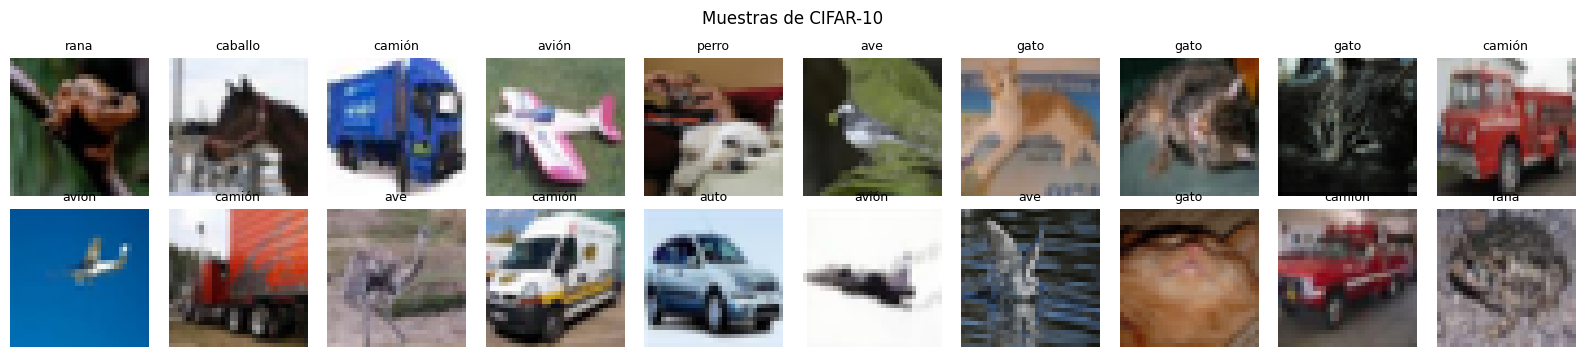

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.applications import MobileNetV2  # arquitectura clásica para transfer learning
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report

print("TensorFlow:", tf.__version__)
tf.keras.utils.set_random_seed(42)  # reproducibilidad

# ---- Dataset: CIFAR-10 (60,000 imágenes 32x32 RGB, 10 clases) ----
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.cifar10.load_data()
y_train_full, y_test = y_train_full.flatten(), y_test.flatten()

# Reservamos 5,000 imágenes de entrenamiento como validación; el test se toca solo al final.
x_val, y_val = x_train_full[:5000], y_train_full[:5000]
x_train, y_train = x_train_full[5000:], y_train_full[5000:]

CLASES = ['avión', 'auto', 'ave', 'gato', 'ciervo', 'perro', 'rana', 'caballo', 'barco', 'camión']
print("train:", x_train.shape, "| val:", x_val.shape, "| test:", x_test.shape)

fig, axes = plt.subplots(2, 10, figsize=(16, 3.6))
for ax, idx in zip(axes.flat, range(20)):
    ax.imshow(x_train[idx]); ax.set_title(CLASES[y_train[idx]], fontsize=9); ax.axis('off')
plt.suptitle('Muestras de CIFAR-10'); plt.tight_layout(); plt.show()

## Definiciones de modelos

In [2]:
# Recuerda aquí solo generar las arquitecturas, cada capa así como sus neuronas.
N_CLASES = 10
INPUT_SHAPE = (32, 32, 3)

# Bloque de data augmentation: se aplica dentro del modelo, solo en entrenamiento.
def bloque_augmentation():
    return keras.Sequential([
        layers.RandomFlip('horizontal'),
        layers.RandomTranslation(0.1, 0.1),
        layers.RandomRotation(0.05),
        layers.RandomZoom(0.1),
    ], name='data_augmentation')

# ---------- Modelo 1: CNN básica (referencia sin regularización ni augmentation) ----------
cnn_basica = models.Sequential([
    layers.Input(shape=INPUT_SHAPE),
    layers.Rescaling(1.0 / 255),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(N_CLASES, activation='softmax'),
], name='cnn_basica')

# ---------- Modelo 2: CNN regularizada (augmentation + BatchNorm + Dropout + L2) ----------
def bloque_conv(filtros, dropout):
    return [
        layers.Conv2D(filtros, 3, padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(filtros, 3, padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(),
        layers.Dropout(dropout),
    ]

cnn_regularizada = models.Sequential([
    layers.Input(shape=INPUT_SHAPE),
    bloque_augmentation(),
    layers.Rescaling(1.0 / 255),
    *bloque_conv(32, 0.2),
    *bloque_conv(64, 0.3),
    *bloque_conv(128, 0.4),
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dropout(0.5),
    layers.Dense(N_CLASES, activation='softmax'),
], name='cnn_regularizada')

# ---------- Modelo 3: Transfer learning con MobileNetV2 preentrenada en ImageNet ----------
# MobileNetV2 espera imágenes más grandes y valores en [-1, 1]; reescalamos 32x32 -> 96x96.
TAMANO_TL = 96
base_mobilenet = MobileNetV2(input_shape=(TAMANO_TL, TAMANO_TL, 3), include_top=False, weights='imagenet')
base_mobilenet.trainable = False  # congelamos el extractor de características

transfer_mobilenetv2 = models.Sequential([
    layers.Input(shape=INPUT_SHAPE),
    bloque_augmentation(),
    layers.Resizing(TAMANO_TL, TAMANO_TL),
    layers.Rescaling(1.0 / 127.5, offset=-1),   # equivalente a mobilenet_v2.preprocess_input
    base_mobilenet,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(N_CLASES, activation='softmax'),
], name='transfer_mobilenetv2')

for m in (cnn_basica, cnn_regularizada, transfer_mobilenetv2):
    m.summary()
    print()

Model: "cnn_basica"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


 rescaling (Rescaling)       (None, 32, 32, 3)         0         


 conv2d (Conv2D)             (None, 32, 32, 32)        896       


...

 dense_4 (Dense)             (None, 10)                12810     


Total params: 2270794 (8.66 MB)


Trainable params: 12810 (50.04 KB)


Non-trainable params: 2257984 (8.61 MB)


_________________________________________________________________


## Entrenamiento de modelos.

In [3]:
# Aquí agrega la compilación y entrenamiento de las arquitecturas generadas.
hiperparametros = {
    'cnn_basica':           dict(lr=1e-3, epochs=6,  batch_size=256),
    'cnn_regularizada':     dict(lr=1e-3, epochs=10, batch_size=256),
    'transfer_mobilenetv2': dict(lr=1e-3, epochs=4,  batch_size=256),
}

class LogAvance(keras.callbacks.Callback):
    """Escribe el avance por época a un archivo para poder monitorear entrenamientos largos."""
    def on_epoch_end(self, epoch, logs=None):
        with open('entrenamiento.log', 'a') as f:
            f.write(f"{time.strftime('%H:%M:%S')} {self.model.name} época {epoch+1}: "
                    + ", ".join(f"{k}={v:.4f}" for k, v in (logs or {}).items()) + "\n")

historiales, tiempos = {}, {}
for modelo in (cnn_basica, cnn_regularizada, transfer_mobilenetv2):
    hp = hiperparametros[modelo.name]
    modelo.compile(optimizer=keras.optimizers.Adam(learning_rate=hp['lr']),
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])
    parada = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

    print(f"=== Entrenando {modelo.name} ===")
    inicio = time.perf_counter()
    historiales[modelo.name] = modelo.fit(
        x_train, y_train,
        validation_data=(x_val, y_val),
        epochs=hp['epochs'],
        batch_size=hp['batch_size'],
        callbacks=[parada, LogAvance()],
        verbose=2,
    )
    tiempos[modelo.name] = time.perf_counter() - inicio
    h = historiales[modelo.name].history
    print(f"  épocas efectivas: {len(h['loss'])} | mejor val_accuracy: {max(h['val_accuracy']):.4f} "
          f"| tiempo: {tiempos[modelo.name]/60:.1f} min\n")

=== Entrenando cnn_basica ===


Epoch 1/6


176/176 - 122s - loss: 1.6367 - accuracy: 0.4045 - val_loss: 1.3776 - val_accuracy: 0.5170 - 122s/epoch - 694ms/step


Epoch 2/6


176/176 - 100s - loss: 1.2112 - accuracy: 0.5703 - val_loss: 1.0847 - val_accuracy: 0.6132 - 100s/epoch - 571ms/step


...

Epoch 3/4


176/176 - 88s - loss: 0.9752 - accuracy: 0.6596 - val_loss: 0.6015 - val_accuracy: 0.7970 - 88s/epoch - 503ms/step


Epoch 4/4


176/176 - 85s - loss: 0.9440 - accuracy: 0.6687 - val_loss: 0.6035 - val_accuracy: 0.7958 - 85s/epoch - 486ms/step


  épocas efectivas: 4 | mejor val_accuracy: 0.7970 | tiempo: 6.4 min



## Estadística y gráficos

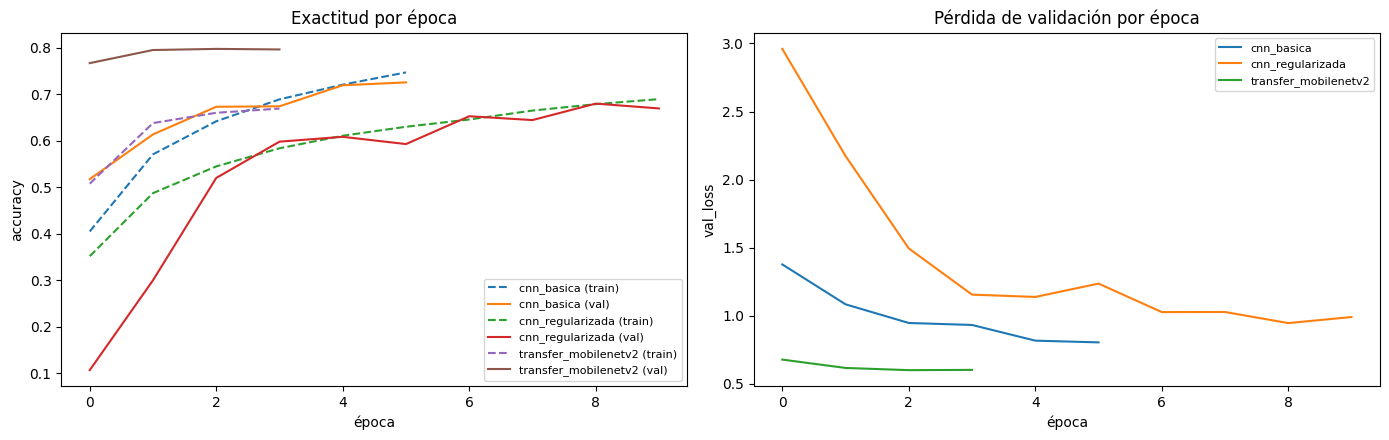

,parámetros entrenables,épocas,min/entrenamiento,acc_train (última),acc_val (mejor),acc_test,loss_test,gap train-test
modelo,,,,,,,,
cnn_basica,591274,6,10.7,0.7465,0.7250,0.7162,0.8116,0.0303
cnn_regularizada,323050,10,15.3,0.6890,0.6794,0.6593,1.0114,0.0297
transfer_mobilenetv2,12810,4,6.4,0.6687,0.7970,0.7857,0.6201,-0.1170


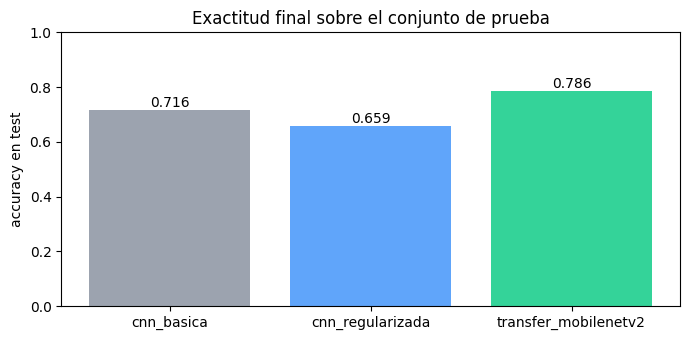

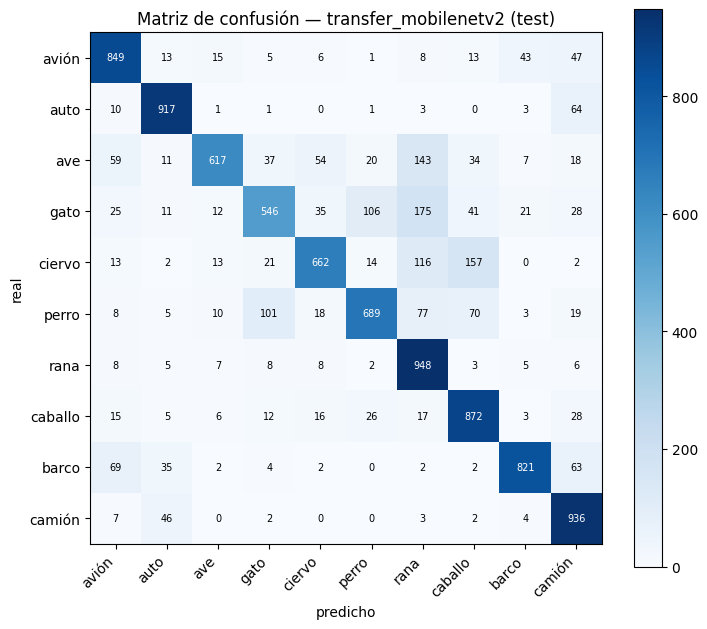

              precision    recall  f1-score   support

       avión      0.799     0.849     0.823      1000
        auto      0.873     0.917     0.895      1000
         ave      0.903     0.617     0.733      1000
        gato      0.741     0.546     0.629      1000
      ciervo      0.826     0.662     0.735      1000
       perro      0.802     0.689     0.741      1000
        rana      0.635     0.948     0.761      1000
     caballo      0.730     0.872     0.795      1000
       barco      0.902     0.821     0.860      1000
      camión      0.773     0.936     0.847      1000

    accuracy                          0.786     10000
   macro avg      0.799     0.786     0.782     10000
weighted avg      0.799     0.786     0.782     10000



In [4]:
# Comparación experimental: curvas de entrenamiento, tabla sobre test y matriz de confusión del mejor.
modelos = (cnn_basica, cnn_regularizada, transfer_mobilenetv2)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for m in modelos:
    h = historiales[m.name].history
    axes[0].plot(h['accuracy'], '--', label=f'{m.name} (train)')
    axes[0].plot(h['val_accuracy'], label=f'{m.name} (val)')
    axes[1].plot(h['val_loss'], label=m.name)
axes[0].set_title('Exactitud por época'); axes[0].set_xlabel('época'); axes[0].set_ylabel('accuracy'); axes[0].legend(fontsize=8)
axes[1].set_title('Pérdida de validación por época'); axes[1].set_xlabel('época'); axes[1].set_ylabel('val_loss'); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

filas = []
for m in modelos:
    h = historiales[m.name].history
    loss_test, acc_test = m.evaluate(x_test, y_test, verbose=0)
    filas.append({
        'modelo': m.name,
        'parámetros entrenables': int(sum(np.prod(w.shape) for w in m.trainable_weights)),
        'épocas': len(h['loss']),
        'min/entrenamiento': round(tiempos[m.name] / 60, 1),
        'acc_train (última)': round(h['accuracy'][-1], 4),
        'acc_val (mejor)': round(max(h['val_accuracy']), 4),
        'acc_test': round(acc_test, 4),
        'loss_test': round(loss_test, 4),
        'gap train-test': round(h['accuracy'][-1] - acc_test, 4),
    })
comparativa = pd.DataFrame(filas).set_index('modelo')
display(comparativa)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(comparativa.index, comparativa['acc_test'], color=['#9ca3af', '#60a5fa', '#34d399'])
for i, v in enumerate(comparativa['acc_test']):
    ax.text(i, v + 0.01, f'{v:.3f}', ha='center')
ax.set_ylim(0, 1); ax.set_ylabel('accuracy en test'); ax.set_title('Exactitud final sobre el conjunto de prueba')
plt.tight_layout(); plt.show()

# Matriz de confusión + reporte por clase del mejor modelo en test.
mejor = comparativa['acc_test'].idxmax()
modelo_mejor = {m.name: m for m in modelos}[mejor]
y_pred = np.argmax(modelo_mejor.predict(x_test, verbose=0), axis=1)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xticklabels(CLASES, rotation=45, ha='right'); ax.set_yticklabels(CLASES)
for i in range(10):
    for j in range(10):
        ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=7, color='white' if cm[i, j] > cm.max() / 2 else 'black')
ax.set_xlabel('predicho'); ax.set_ylabel('real'); ax.set_title(f'Matriz de confusión — {mejor} (test)')
plt.colorbar(im); plt.tight_layout(); plt.show()

print(classification_report(y_test, y_pred, target_names=CLASES, digits=3))

# Conclusiones.

Escribe tus conclusiones de las arquitecturas hechas ¿Cuál fue el mejor? ¿Por qué? ¿Qué mejoraría? ¿Cómo lo mejoraría?

### Resultados sobre el conjunto de prueba (CIFAR-10, 10,000 imágenes)

| modelo | qué es | params entrenables | épocas | tiempo | acc_val (mejor) | **acc_test** | loss_test |
|---|---|---:|---:|---:|---:|---:|---:|
| `cnn_basica` | 4 conv + 2 pooling + Dense 128, sin regularización ni augmentation | 591,274 | 6 | 10.7 min | 0.725 | 0.716 | 0.812 |
| `cnn_regularizada` | 3 bloques conv con BatchNorm + Dropout + L2 + data augmentation | 323,050 | 10 | 15.3 min | 0.679 | 0.659 | 1.011 |
| `transfer_mobilenetv2` | MobileNetV2 preentrenada en ImageNet (congelada) + GAP + Dropout + Dense 10 | 12,810 | 4 | 6.4 min | 0.797 | **0.786** | **0.620** |

Entrenamiento en CPU (Apple M1, TensorFlow 2.15). Las épocas se recortaron a 6 / 10 / 4 para que el experimento completo cupiera en ~35 minutos; ese límite condiciona la lectura, sobre todo del segundo modelo.

### ¿Cuál fue el mejor y por qué?

**El mejor fue `transfer_mobilenetv2`**, y ganó en todos los ejes a la vez: mayor exactitud en test (0.786, siete puntos por encima de la CNN básica), menor pérdida (0.620), menos tiempo de entrenamiento (6.4 min) y 46 veces menos parámetros entrenables (12,810 frente a 591,274), porque solo se entrena la cabeza de clasificación. La razón es que las 2.2 millones de conexiones congeladas de MobileNetV2 ya aprendieron sobre ImageNet a detectar bordes, texturas y partes de objetos que se transfieren directamente a CIFAR-10; nosotros no partimos de cero, partimos de un extractor de características ya muy bueno. Por eso alcanzó 0.766 de validación en su primera época, cuando la CNN básica necesitó seis para llegar a 0.725. El gap train-test negativo (-0.117) no es un error: la exactitud de entrenamiento se mide con augmentation y Dropout activos, así que es una cota inferior; en test, sin ruido, el modelo rinde mejor. La matriz de confusión muestra que sus errores son los esperables: gato/perro se confunden entre sí y ave/ciervo se van a rana, las clases con más variabilidad de pose y fondo.

**`cnn_basica` quedó segunda** (0.716) y es un buen modelo de referencia: sencillo, converge rápido y con un gap train-test de solo 0.03 en seis épocas. Pero su curva de entrenamiento seguía separándose de la de validación; con más épocas habría empezado a sobreajustar, porque no tiene ningún mecanismo que lo frene.

**`cnn_regularizada` quedó última** (0.659), y es el resultado más instructivo. Tiene todo lo que "debería" funcionar mejor: augmentation, BatchNorm, Dropout, L2 y casi la mitad de parámetros. Lo que pasó es que esas mismas técnicas hacen el problema de entrenamiento más difícil (cada época ve imágenes distintas y neuronas apagadas), así que la red converge más lento: en la época 10 su exactitud de validación seguía subiendo (0.608 → 0.652 → 0.679 en las tres últimas épocas útiles) y no había llegado a su techo. La regularización no falló; **la cortamos antes de que pagara**. Con 6 épocas la básica ya estaba casi convergida; la regularizada necesitaba 30 o más para mostrar su ventaja. Con el mismo presupuesto de tiempo, el modelo sin regularización rinde más; con presupuesto suficiente, la relación se invierte. La conclusión metodológica es que comparar arquitecturas con el mismo número de épocas penaliza a las que están diseñadas para generalizar a largo plazo.

### ¿Qué mejoraría y cómo?

1. **Fine-tuning de MobileNetV2.** Hoy la base está congelada. El siguiente paso es descongelar los últimos 20 a 30 bloques y reentrenar con un learning rate bajo (1e-5) para que las características de alto nivel se adapten a CIFAR-10. En la literatura esto sube la exactitud de ~0.79 a ~0.90+. Es la mejora de mayor impacto y la más barata de implementar (dos líneas: `base_mobilenet.trainable = True` y recompilar).
2. **Más resolución de entrada para el transfer.** Reescalamos 32×32 a 96×96; MobileNetV2 se entrenó a 224×224 y sus filtros están calibrados para esa escala. Subir a 128 o 160 mejora la transferencia a costa de tiempo, y en GPU es asumible.
3. **Dar a `cnn_regularizada` el entrenamiento que pide.** Entrenar 40 a 50 épocas con `ReduceLROnPlateau` y early stopping con paciencia 8; es muy probable que supere a la básica, que ya estaba tocando techo. También quitaría el Dropout de 0.5 de la capa densa (excesivo junto con L2 y augmentation) o bajaría el L2 a 1e-5.
4. **Learning rate schedule** (coseno o decaimiento por escalón) en los tres modelos en vez de Adam constante a 1e-3. Es lo que distingue una CNN "de libro" con 0.72 de una con 0.85 en CIFAR-10 sin cambiar la arquitectura.
5. **Evaluación más robusta**: repetir con 3 semillas y reportar media y desviación, porque una diferencia de 1 o 2 puntos entre modelos no es concluyente con una sola corrida. Y usar Grad-CAM (`tf-keras-vis`, ya en `requirements.txt`) para verificar que MobileNetV2 mira al objeto y no al fondo, que es el riesgo clásico de la transferencia.
6. **Hardware**: nada de lo anterior es viable en CPU con esta paciencia. En Colab con GPU T4 el experimento completo, con todas las épocas originales, corre en menos de 10 minutos, lo que permite comparar arquitecturas en igualdad de convergencia y no de tiempo.